
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Lenovo\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Lenovo\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Lenovo\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Lenovo\anaconda3\Lib\site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




Results
Laser λ (nm)   Average b   N     L (µm)
  Red  692.0 -0.29935537 437 151.098423
Green  532.0  0.01659666 568 151.092415
-----------------------------------------------------------------
Optimal L       : 151.095462 µm
|L1 - L2|       : 0.006008 µm
Min. normalized : 3.834941e-04


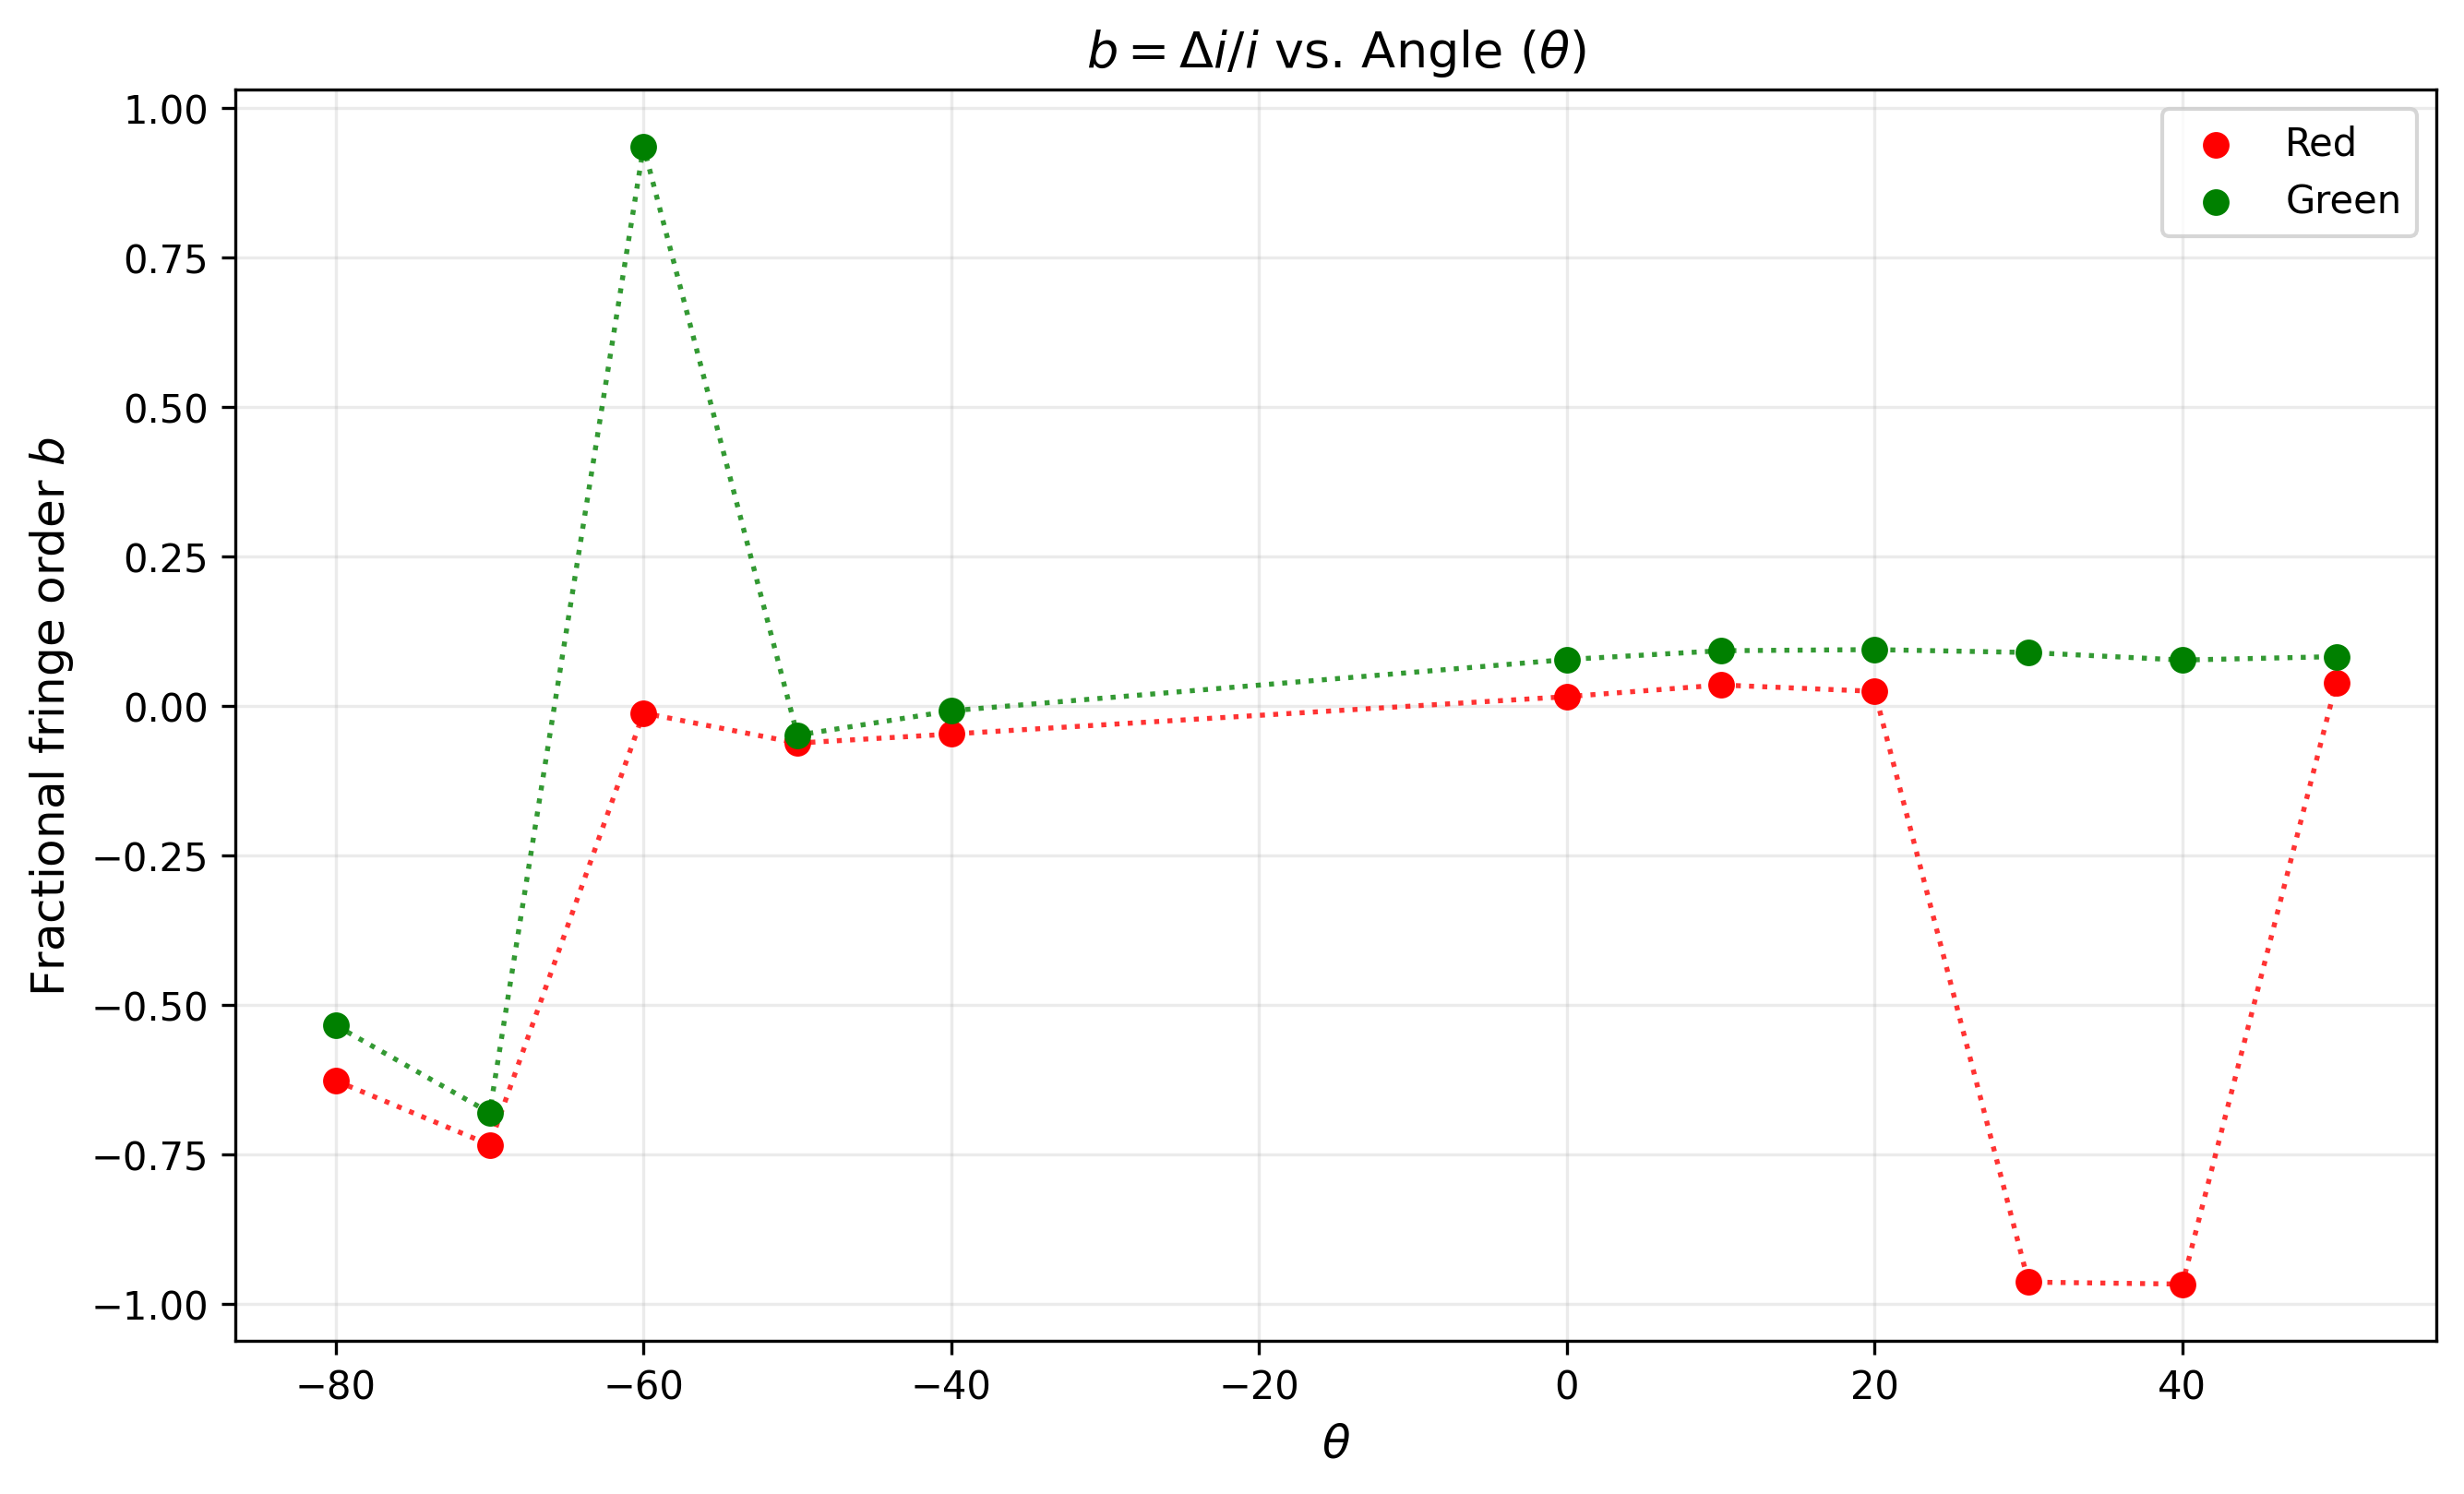

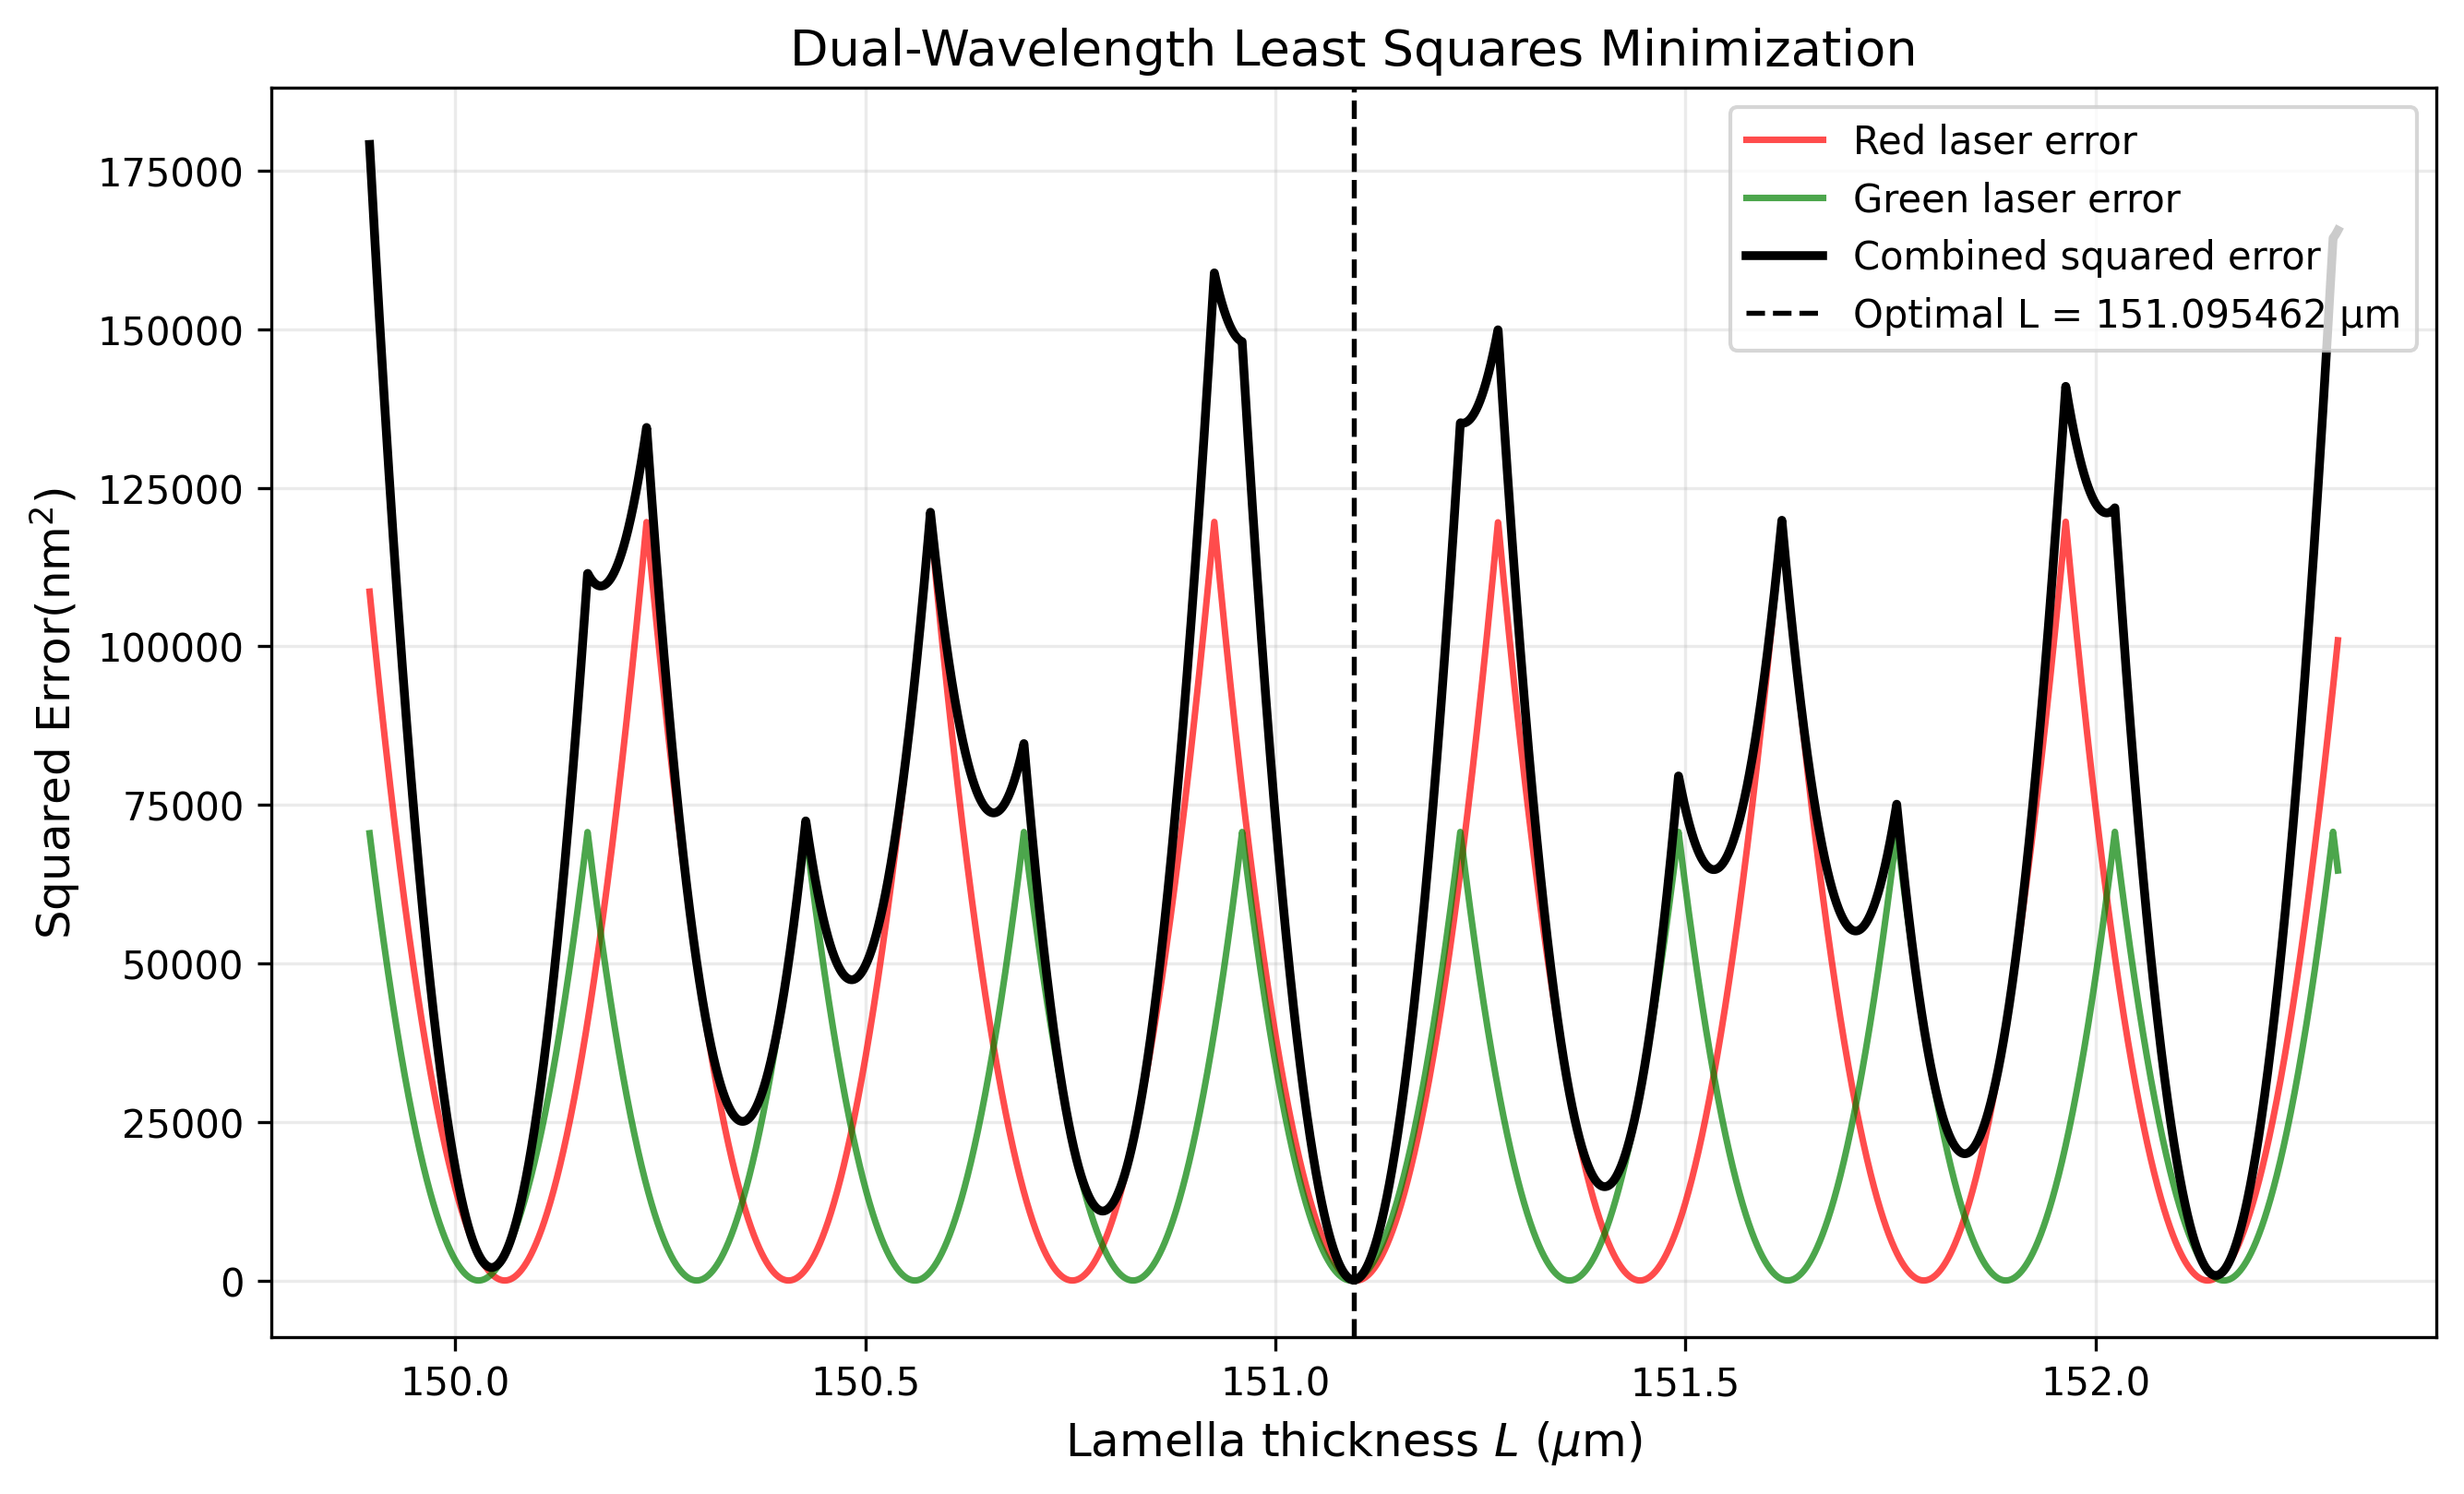

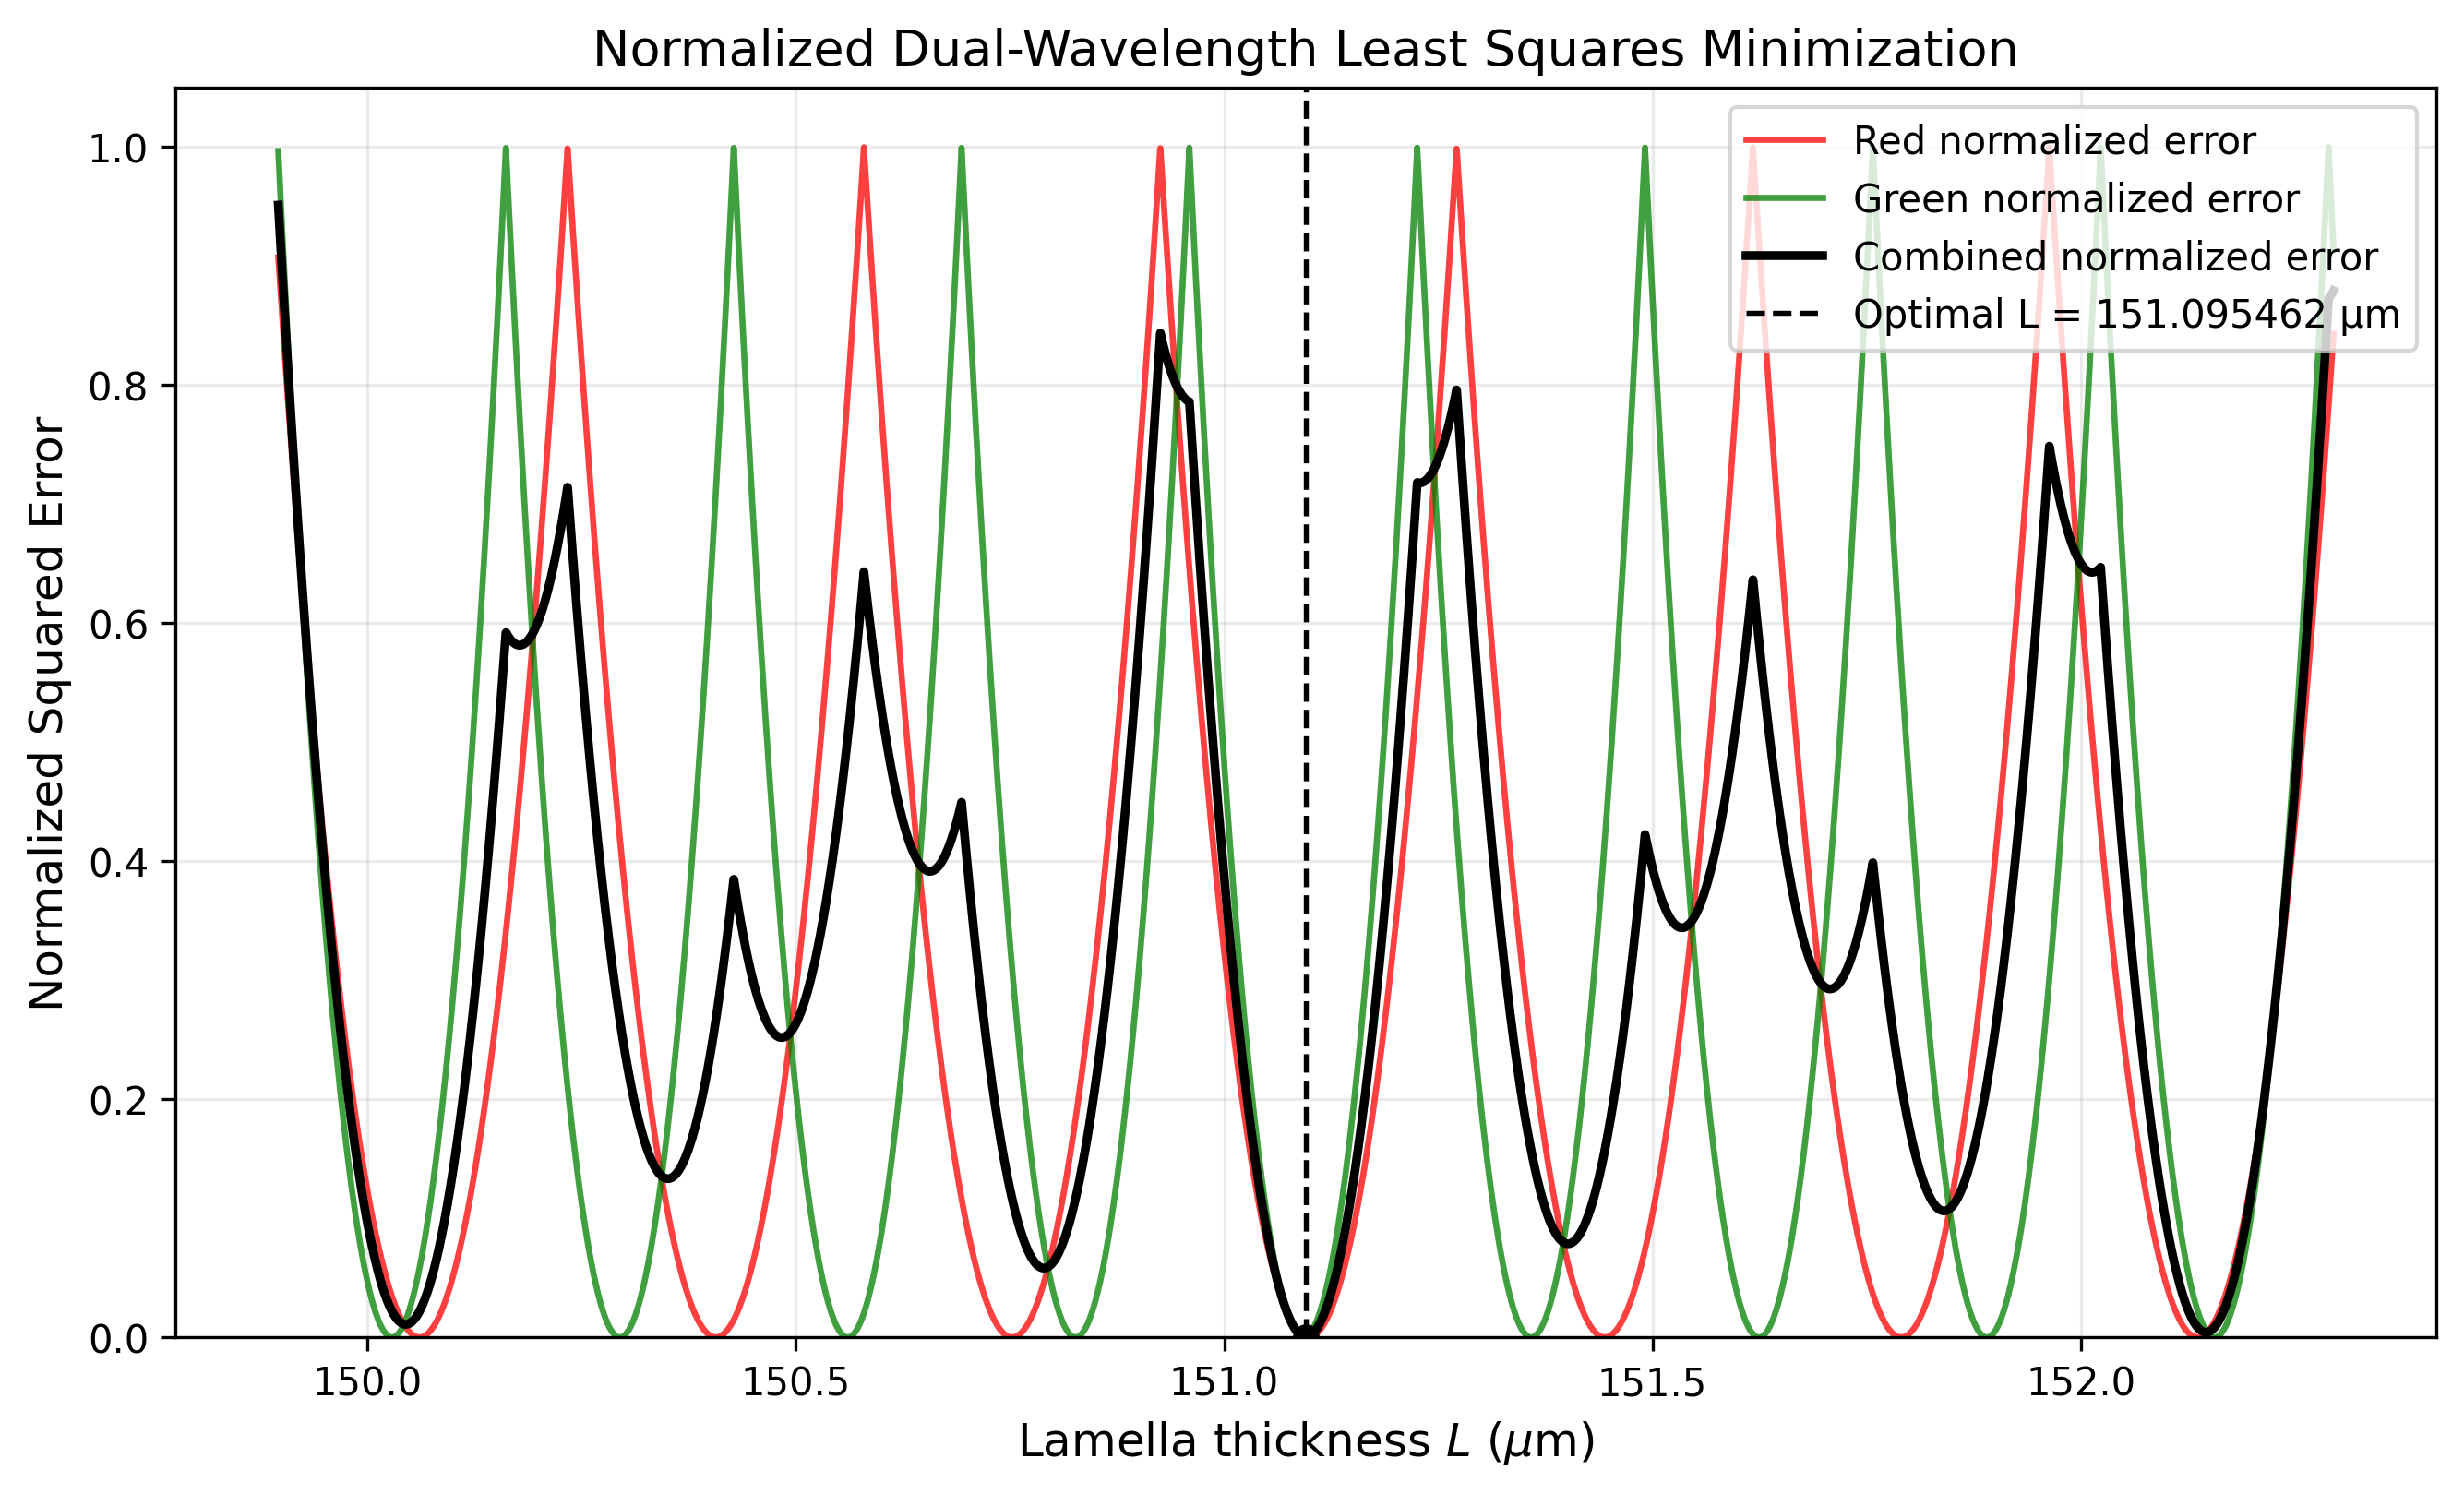


Saved: C:\Users\Lenovo\Downloads\Book1_with_new_b.xlsx


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


folder = r'C:\Users\Lenovo\Downloads'
input_file = os.path.join(folder,'Book1_cleaned.xlsx')
output_file = os.path.join(folder,'Book1_with_new_b.xlsx')

# Laser wavelengths (nm)
WAVELENGTHS = {'Red': 692.0,'Green': 532.0,'Blue': 405.0}

# Expected thickness and search range
L_target_um = 155.0
search_width_um = 7.0

# Number of points in the L search
n_points = 50000

df = pd.read_excel(input_file)
df.columns = [ str(c).strip() for c in df.columns]

required_columns = ['Image','Period (i)','Shift (Δi)','Fractional b','color','theta']

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}\n'f'Available columns: {df.columns.tolist()}' )


# Clean data
df['Period (i)'] = pd.to_numeric( df['Period (i)'], errors='coerce')
df['Shift (Δi)'] = pd.to_numeric(df['Shift (Δi)'],errors='coerce')
df['theta'] = pd.to_numeric(df['theta'],errors='coerce')
df['color'] = (df['color'].astype(str).str.strip() .str.capitalize())
df = df.dropna(subset=['Period (i)','Shift (Δi)','color' ]).copy()

# Calculate fractional fringe order
# b = Δi / i
df.loc[ df['Period (i)'] == 0,'Period (i)'] = np.nan
df['Fractional b'] = (df['Shift (Δi)']/ df['Period (i)'])
df = df.dropna(subset=['Fractional b']).copy()

# Average b for each laser
average_b = {}
for color in WAVELENGTHS:
    values = df.loc[ df['color'] == color,'Fractional b' ]
    if len(values) > 0:
        average_b[color] = values.mean()

active_colors = list(average_b.keys())
if len(active_colors) < 2:
    raise ValueError('At least two laser colors are required.')


# Select the first two available lasers
c1 = active_colors[0]
c2 = active_colors[1]

lambda1 = WAVELENGTHS[c1]
lambda2 = WAVELENGTHS[c2]

b1 = average_b[c1]
b2 = average_b[c2]

# Search for L
L_test_um = np.linspace( L_target_um - search_width_um, L_target_um + search_width_um, n_points)
# Convert µm to nm because wavelengths are in nm
L_test_nm = (L_test_um * 1000.0)

# Integer fringe orders N = 2L / λ - b
N1 = np.round(2 * L_test_nm / lambda1 - b1).astype(int)
N2 = np.round(2 * L_test_nm / lambda2 - b2).astype(int)
# error   B_i = 2L - (N_i + b_i) λ_i
error1 = (2 * L_test_nm - (N1 + b1) * lambda1)
error2 = (2 * L_test_nm- (N2 + b2) * lambda2)
# Squared error
error1 = error1 ** 2
error2 = error2 ** 2

# The function being minimized:  Σ [2L - (N_i + b_i) λ_i]^2
error_total = (error1 + error2)

# Find the minimum
best_idx = np.argmin(error_total)
best_L_um = (L_test_um[best_idx])
best_N1 = (N1[best_idx])
best_N2 = (N2[best_idx])

# Calculate L independently from each laser
L1_um = ( (best_N1 + b1) * lambda1 / 2 / 1000)
L2_um = ( (best_N2 + b2) * lambda2/ 2 / 1000)


# Normalize the error
normalized_error1 = (error1 / np.max(error1))
normalized_error2 = (error2 / np.max(error2))
normalized_total = (error_total / np.max(error_total))


# Print compact results
results = pd.DataFrame({'Laser': [c1, c2],'λ (nm)': [lambda1, lambda2],'Average b': [b1, b2],'N': [best_N1, best_N2],'L (µm)': [L1_um, L2_um]})
print('\n' + '=' * 65)
print('Results')
print('=' * 65)
print(results.to_string(index=False,formatters={ 'λ (nm)': '{:.1f}'.format,'Average b': '{:.8f}'.format, 'L (µm)': '{:.6f}'.format}))
print('-' * 65)
print(f'Optimal L       : {best_L_um:.6f} µm')
print(f'|L1 - L2|       : ' f'{abs(L1_um - L2_um):.6f} µm')
print( f'Min. normalized : 'f'{normalized_total[best_idx]:.6e}')
print('=' * 65)

# plots
plot_colors = {'Red': 'red','Green': 'green','Blue': 'blue'}
color1 = plot_colors.get(c1, 'blue')
color2 = plot_colors.get(c2,'blue')

# Figure 1 — b versus theta
plt.figure( figsize=(9, 5.5),dpi=300)
for color in active_colors:
    data = (df[df['color'] == color].sort_values('theta'))
    plt.scatter(data['theta'],data['Fractional b'],color=plot_colors[color],s=35,zorder=3,label=color)
    plt.plot(data['theta'],data['Fractional b'],color=plot_colors[color],linestyle=':',linewidth=1.3,alpha=0.8)
plt.xlabel(r'$\theta$',fontsize=12)
plt.ylabel(r'Fractional fringe order $b$',fontsize=12)
plt.title(r'$b = \Delta i / i$ vs. Angle ($\theta$)',fontsize=13)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2 — individual and combined error
zoom = ( (L_test_um >= best_L_um - 1.2) & (L_test_um <= best_L_um + 1.2))
plt.figure(figsize=(9, 5.5),dpi=300)
plt.plot(L_test_um[zoom],error1[zoom],color=color1,linewidth=1.7,alpha=0.7,label=f'{c1} laser error')
plt.plot(L_test_um[zoom],error2[zoom],color=color2,linewidth=1.7,alpha=0.7,label=f'{c2} laser error')
plt.plot(L_test_um[zoom],error_total[zoom],color='black',linewidth=2.3,label='Combined squared error')
plt.axvline(best_L_um,color='black',linestyle='--',linewidth=1.3,label=f'Optimal L = {best_L_um:.6f} µm')
plt.xlabel(r'Lamella thickness $L$ ($\mu$m)',fontsize=12)
plt.ylabel(r'Squared Error(nm$^2$)',fontsize=12)
plt.title('Dual-Wavelength Least Squares Minimization',fontsize=13)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 3 — normalized error
plt.figure(figsize=(9, 5.5),dpi=300)
plt.plot(L_test_um[zoom],normalized_error1[zoom],color=color1,linewidth=1.6,alpha=0.75,label=f'{c1} normalized error')
plt.plot(L_test_um[zoom],normalized_error2[zoom],color=color2,linewidth=1.6,alpha=0.75,label=f'{c2} normalized error')
plt.plot( L_test_um[zoom],normalized_total[zoom],color='black',linewidth=2.3,label='Combined normalized error')
plt.axvline( best_L_um,color='black',linestyle='--',linewidth=1.3,label=f'Optimal L = {best_L_um:.6f} µm')
plt.scatter(best_L_um,normalized_total[best_idx],color='black',s=35, zorder=3)
plt.xlabel( r'Lamella thickness $L$ ($\mu$m)', fontsize=12)
plt.ylabel('Normalized Squared Error',fontsize=12)
plt.title('Normalized Dual-Wavelength Least Squares Minimization',fontsize=13)
plt.ylim( 0, 1.05)
plt.grid( alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# Save results to Excel
average_table = pd.DataFrame({
    'color': list(average_b.keys()),
    'Wavelength (nm)': [
        WAVELENGTHS[c]
        for c in average_b
    ],
    'Average Fractional b': [
        average_b[c]
        for c in average_b
    ]
})

final_table = pd.DataFrame({
    'Laser 1': [c1],
    'Wavelength 1 (nm)': [lambda1],
    'Average b1': [b1],
    'N1': [best_N1],

    'Laser 2': [c2],
    'Wavelength 2 (nm)': [lambda2],
    'Average b2': [b2],
    'N2': [best_N2],

    'L from Laser 1 (µm)': [L1_um],
    'L from Laser 2 (µm)': [L2_um],
    'Optimal L (µm)': [best_L_um],

    'L difference (µm)': [abs(L1_um - L2_um) ],
    'Minimum normalized error': [normalized_total[best_idx]]
})


with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df.to_excel(writer,sheet_name='Data_with_b',index=False)
    average_table.to_excel(writer,sheet_name='Average_b',index=False)
    final_table.to_excel(writer,sheet_name='Results',index=False)

print(f'\nSaved: {output_file}')

<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1301/3326406028.py:133: SyntaxWarning: invalid escape sequence '\l'
  ['$f_{Red}$', '$f_{Green}$', '$\lambda_{Red}$', '$\lambda_{Green}$', 'Align', '$n_{air}$'],
/tmp/ipykernel_1301/3326406028.py:133: SyntaxWarning: invalid escape sequence '\l'
  ['$f_{Red}$', '$f_{Green}$', '$\lambda_{Red}$', '$\lambda_{Green}$', 'Align', '$n_{air}$'],



     بودجه عدم قطعیت ترکیبی دو طول‌موجی برای ضخامت لامل (L = 157.0411 µm)
                  Source Sensitivity (c_i) Contribution u_i(L) [nm] Variance Share (%)
  Red Fringe Phase (f_R)            158.16                    2.372             46.97%
Green Fringe Phase (f_G)            132.96                    1.994             33.20%
    Red Wavelength (λ_R)            124.08                    0.620              3.21%
  Green Wavelength (λ_G)            147.60                    0.738              4.55%
Alignment & Cosine Error              1.00                    1.200             12.02%
Air Refractive Index (n)         156998.71                    0.078              0.05%
------------------------------------------------------------------------------
عدم قطعیت مرکب استاندارد (u_c): 3.461 nm  (0.00346 µm)
عدم قطعیت گسترده (U, k=2):      6.923 nm  (0.00692 µm)
نتیجه نهایی گزارش: L = (157.0411 ± 0.0069) µm



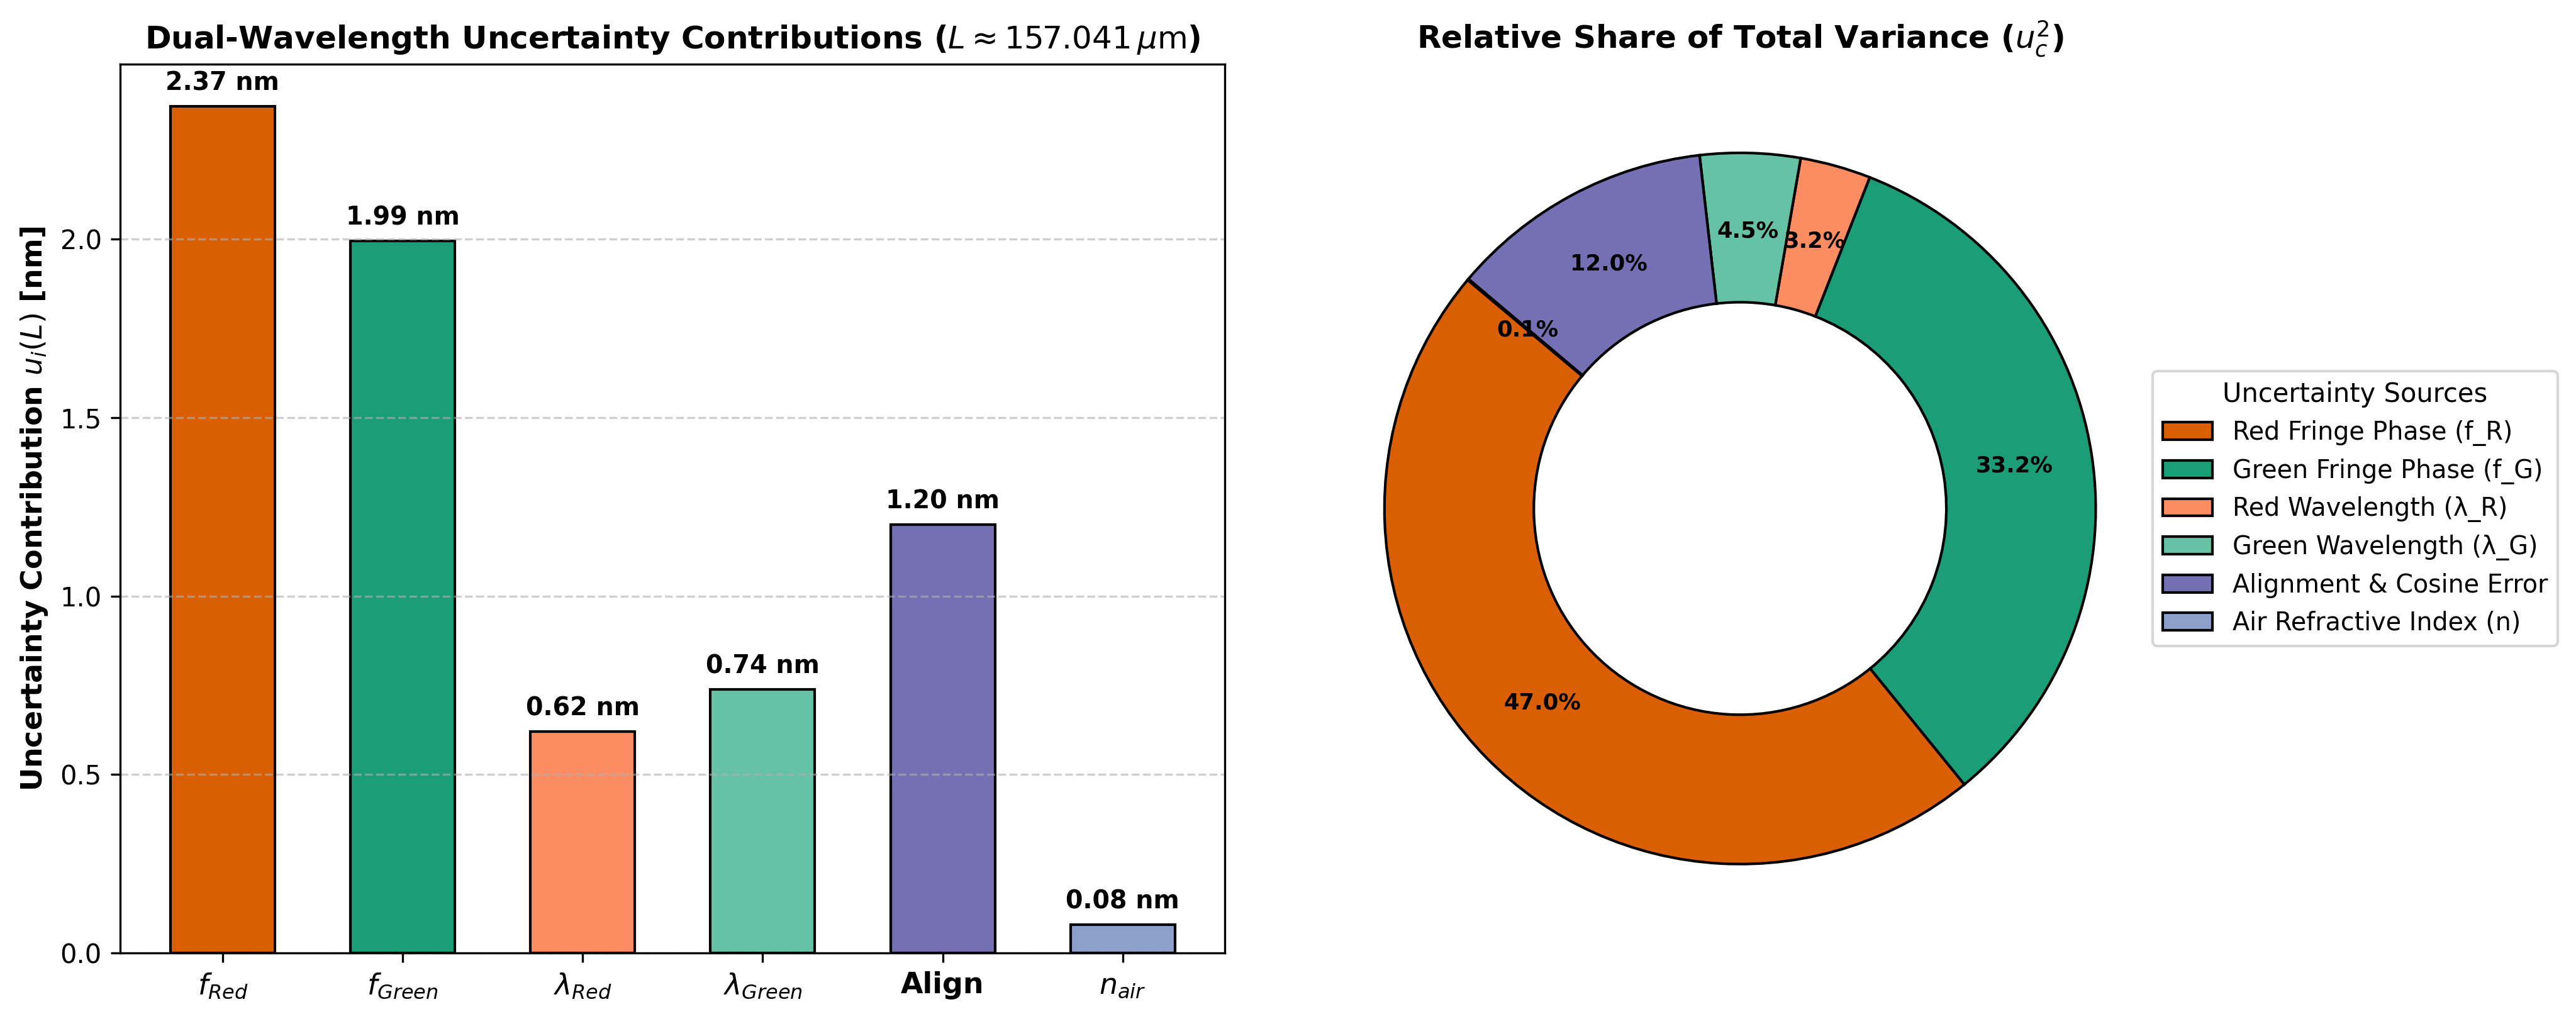

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ========================================================
# Laboratory parameters for both wavelengths
# ========================================================
L_um = 157.0411
L_nm = L_um * 1000.0
n_air = 1.00027

# Red light specifications
lambda_R = 632.8  # nm
N_R = 496
b_R = 0.3370
u_f_R = 0.015  # uncertainty of red fringe fraction
u_lambda_R = 0.005  # uncertainty of red wavelength (nm)

# Green light specifications
lambda_G = 532.0  # nm
N_G = 590
b_G = 0.3802
u_f_G = 0.015  # uncertainty of green fringe fraction
u_lambda_G = 0.005  # uncertainty of green wavelength (nm)

# Environmental and mechanical conditions
u_n = 5.0e-7  # uncertainty of air refractive index
u_align = 1.20  # uncertainty of alignment and cosine error (nm)

# ========================================================
# Analytical sensitivity coefficients (partial derivatives dL/dx_i)
# Based on the analytical model: L = (L_Red + L_Green) / 2
# ========================================================
c_f_R = lambda_R / (4.0 * n_air)
c_f_G = lambda_G / (4.0 * n_air)

c_lambda_R = L_nm / (2.0 * lambda_R)
c_lambda_G = L_nm / (2.0 * lambda_G)

c_n = L_nm / n_air

# ========================================================
# Calculate the uncertainty contribution of each component (in nanometers)
# ========================================================
u_L_f_R = c_f_R * u_f_R  # red fringe fraction contribution
u_L_f_G = c_f_G * u_f_G  # green fringe fraction contribution
u_L_lam_R = c_lambda_R * u_lambda_R  # red wavelength contribution
u_L_lam_G = c_lambda_G * u_lambda_G  # green wavelength contribution
u_L_n = c_n * u_n  # air refractive index contribution
u_L_align = u_align  # alignment error contribution

labels = [
    'Red Fringe Phase (f_R)',
    'Green Fringe Phase (f_G)',
    'Red Wavelength (λ_R)',
    'Green Wavelength (λ_G)',
    'Alignment & Cosine Error',
    'Air Refractive Index (n)',
]

u_contributions = [
    u_L_f_R,
    u_L_f_G,
    u_L_lam_R,
    u_L_lam_G,
    u_L_align,
    u_L_n,
]
variances = [u**2 for u in u_contributions]

# Combined standard uncertainty (u_c)
u_c_nm = np.sqrt(sum(variances))
u_c_um = u_c_nm / 1000.0

# Expanded uncertainty (k=2 -> 95% confidence level)
U_expanded_nm = 2.0 * u_c_nm
U_expanded_um = U_expanded_nm / 1000.0

percent_shares = [(v / sum(variances)) * 100.0 for v in variances]




df_budget = pd.DataFrame(
    {
        'Source': labels,
        'Sensitivity (c_i)': [
            f'{c_f_R:.2f}',
            f'{c_f_G:.2f}',
            f'{c_lambda_R:.2f}',
            f'{c_lambda_G:.2f}',
            '1.00',
            f'{c_n:.2f}',
        ],
        'Contribution u_i(L) [nm]': [f'{u:.3f}' for u in u_contributions],
        'Variance Share (%)': [f'{p:.2f}%' for p in percent_shares],
    }
)

print("\n" + "=" * 78)
print(
    f"     Combined dual-wavelength uncertainty budget for lamella thickness (L = {L_um:.4f} µm)"
)
print("=" * 78)
print(df_budget.to_string(index=False))
print("-" * 78)
print(
    f"Combined standard uncertainty (u_c): {u_c_nm:.3f} nm  ({u_c_um:.5f} µm)"
)
print(
    f"Expanded uncertainty (U, k=2):      {U_expanded_nm:.3f} nm  ({U_expanded_um:.5f} µm)"
)
print(f"Final reported result: L = ({L_um:.4f} ± {U_expanded_um:.4f}) µm")
print("=" * 78 + "\n")



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)

plot_colors = ['#d95f02', '#1b9e77', '#fc8d62', '#66c2a5', '#7570b3', '#8da0cb']

bars = ax1.bar(
    range(len(labels)),
    u_contributions,
    color=plot_colors,
    edgecolor='black',
    width=0.58,
)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(
    ['$f_{Red}$', '$f_{Green}$', '$\lambda_{Red}$', '$\lambda_{Green}$', 'Align', '$n_{air}$'],
    fontsize=11,
    fontweight='bold',
)
ax1.set_ylabel(
    'Uncertainty Contribution $u_i(L)$ [nm]', fontsize=11, fontweight='bold'
)
ax1.set_title(
    r'Dual-Wavelength Uncertainty Contributions ($L \approx 157.041\,\mu\mathrm{m}$)',
    fontsize=12,
    fontweight='bold',
)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    h = bar.get_height()
    ax1.annotate(
        f'{h:.2f} nm',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9.5,
        fontweight='bold',
    )


wedges, texts, autotexts = ax2.pie(
    variances,
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.78,
    colors=plot_colors,
    startangle=140,
    wedgeprops=dict(width=0.42, edgecolor='black'),
)
for at in autotexts:
    at.set_color('black')
    at.set_fontsize(8.5)
    at.set_fontweight('bold')

ax2.legend(
    wedges,
    labels,
    title='Uncertainty Sources',
    loc='center left',
    bbox_to_anchor=(0.95, 0.5),
    fontsize=9.5,
)
ax2.set_title(
    'Relative Share of Total Variance ($u_c^2$)', fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    'Figure_5_1_Dual_Wavelength_Uncertainty_Budget.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()